<a href="https://colab.research.google.com/github/malehzja/final_lis4693/blob/main/final-project/DescriptiveAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**

# Task 1: Text Analysis and Visualization

# 2️⃣ **Descriptive Analysis and Visualiziation Using Altair**

### Installing Libraries

In [3]:
import pandas as pd
import altair as alt
from vega_datasets import data as vega_data

# Importing File

In [11]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/final_lis4693/refs/heads/main/final-project/imdb_tvshows.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
text = response.text

Save it as a DataFrame using `df` variable that holds pandas DataFrame and see how it looks.

In [12]:
seattle_df = pd.read_csv(io.StringIO(text))
seattle_df.head()

,Unnamed: 0,Rating (out of 10),Review,Show ID,Review ID
0,0,9,Andor was every bit as good as I was hoping fo...,tt9253284,rw10514299
1,1,10,Wow. I just finished episode 12 of the first s...,tt9253284,rw8690571
2,2,10,Andor Season 2 is the best Star Wars Show ever...,tt9253284,rw10514285
3,3,9,There were a few episodes I didn't like in bot...,tt9253284,rw10514788
4,4,9,Didnt like the new movies and even Mandalorian...,tt9253284,rw8665236


# Simple Bar Graph

<Axes: xlabel='Rating (out of 10)'>

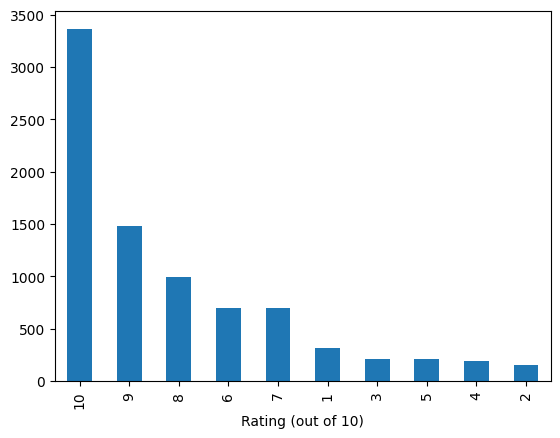

In [13]:
seattle_df['Rating (out of 10)'].value_counts().plot(kind='bar')

# Data Frame

In [14]:
type(seattle_df['Rating (out of 10)'].value_counts())

pandas.core.series.Series

In [15]:
seattle_df['Rating (out of 10)'].value_counts().rename_axis('Rating (out of 10)').reset_index(name='counts')

,Rating (out of 10),counts
0,10,3362
1,9,1480
2,8,998
3,6,700
4,7,697
5,1,315
6,3,213
7,5,212
8,4,189
9,2,153


# Altair Charts

In [16]:
source = seattle_df['Rating (out of 10)'].value_counts().rename_axis('Rating (out of 10)').reset_index(name='counts')
alt.Chart(source).mark_bar().encode(
    x='Rating (out of 10)',
    y='counts'
)

alt.Chart(...)

**Show Names (manually looked up)**   
tt9253284 = Andor   
tt3581920 = The Last of Us    
tt5834204 = The Handmaids Tale  
tt4236770 = Yellowstone   
tt9288030 = Reacher   
tt2442560 = Peaky Blinders    
tt13443470 = Wednesday    
tt8111088 = The Mandalorian   
tt5180504 = The Witcher   
tt13406094 = The White Lotus

In [18]:
seattle_material_grouped = seattle_df.groupby(
    ["Show ID", "Rating (out of 10)"]
).size().reset_index(name="counts")

In [19]:
seattle_material_grouped["Show Name"] = seattle_material_grouped["Show ID"].astype(str).map({
    "tt9253284": "Andor",
    "tt3581920": "The Last of Us",
    "tt5834204": "The Handmaid's Tale",
    "tt4236770": "Yellowstone",
    "tt9288030": "Reacher",
    "tt2442560": "Peaky Blinders",
    "tt13443470": "Wednesday",
    "tt8111088": "The Mandalorian",
    "tt5180504": "The Witcher",
    "tt13406094": "The White Lotus"
})

In [20]:
selection = alt.selection_point(fields=['Show Name'], bind='legend')
alt.Chart(seattle_material_grouped).mark_bar().encode(
    x=alt.X('Rating (out of 10)', sort='-y'),
    y='counts',
    color=alt.Color('Show Name:N', sort=alt.EncodingSortField('Show Name', order='descending')),
    tooltip=['Show Name', 'counts', 'Show Name'],
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    order='Show Name'
).add_params(
    selection
)

alt.Chart(...)